# IMPORTING LIBRARIES

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re   #Regular Expressions
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Loading Dataset

In [12]:
df = pd.read_csv('training.1600000.processed.noemoticon.csv',encoding='latin-1')

In [13]:
df.head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [14]:
df.shape

(1048572, 6)

# Exploratory Data Analysis (EDA)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048572 entries, 0 to 1048571
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype
---  ------              --------------    -----
 0   polarity of tweet   1048572 non-null  int64
 1   id of the tweet     1048572 non-null  int64
 2   date of the tweet   1048572 non-null  str  
 3   query               1048572 non-null  str  
 4   user                1048572 non-null  str  
 5   text of the tweet   1048572 non-null  str  
dtypes: int64(2), str(4)
memory usage: 168.5 MB


In [16]:
df.isnull().sum()

polarity of tweet     0
id of the tweet       0
date of the tweet     0
query                 0
user                  0
text of the tweet     0
dtype: int64

In [ ]:
df['polarity of tweet\xa0'].value_counts()

polarity of tweet 
0    799996
4    248576
Name: count, dtype: int64

In [19]:
df['query'].value_counts()


query
NO_QUERY    1048572
Name: count, dtype: int64

In [20]:
df['user'].value_counts()


user
lost_dog           549
tweetpet           310
webwoke            264
mcraddictal        238
wowlew             210
                  ... 
alyari               1
ahousley             1
timg888              1
Madelinedugganx      1
Falchion             1
Name: count, Length: 511364, dtype: int64

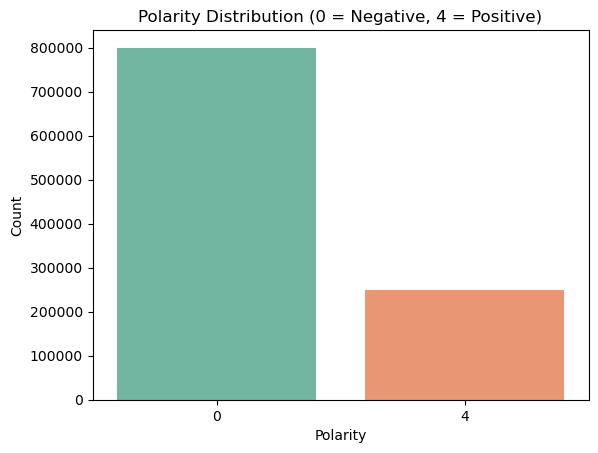

In [22]:
sns.countplot(x='polarity of tweet\xa0', data=df, palette='Set2')
plt.title('Polarity Distribution (0 = Negative, 4 = Positive)')
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.show()


# Data Preprocessing

In [24]:
df.columns

Index(['polarity of tweet ', 'id of the tweet', 'date of the tweet', 'query',
       'user', 'text of the tweet '],
      dtype='str')

In [25]:
df = df[['polarity of tweet\xa0','text of the tweet\xa0']]

In [27]:
df['polarity of tweet\xa0'] = df['polarity of tweet\xa0'].replace(4, 1)

In [29]:
print("Updated Polarity Distribution:")
print(df['polarity of tweet\xa0'].value_counts())


Updated Polarity Distribution:
polarity of tweet 
0    799996
1    248576
Name: count, dtype: int64


**0 = Negative ; 1 = Positive**

In [34]:
df.head()

,polarity of tweet,text of the tweet
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


# Text Cleaning

In [35]:
def clean_text(text):

    text = text.lower()   # Converting to lowercase

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Removing URL's

    text = re.sub(r'@\w+', '', text)   # Removing @mentions

    text = re.sub(r'#\w+', '', text)   # Removing #tags

    text = text.translate(str.maketrans('', '', string.punctuation))   # Removing Punctuations
    
    text = re.sub(r'\d+', '', text)   # Removing Numbers

    text = text.strip()      # Removing Extra Whitespaces

    return text



In [37]:
df['clean_text'] = df['text of the tweet\xa0'].apply(clean_text)

In [39]:
print("Original Text:")
print(df['text of the tweet\xa0'][0])
print("\nCleaned Text:")
print(df['clean_text'][0])

Original Text:
is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

Cleaned Text:
is upset that he cant update his facebook by texting it and might cry as a result  school today also blah


In [40]:
df.head()

,polarity of tweet,text of the tweet,clean_text
0,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
1,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
2,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...
4,0,@Kwesidei not the whole crew,not the whole crew


# Train Test Split

In [41]:
X = df['clean_text']
y = df['polarity of tweet\xa0']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [43]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining Polarity Distribution:")
print(y_train.value_counts())

print("\nTesting Polarity Distribution:")
print(y_test.value_counts())

Training set size: (838857,)
Testing set size: (209715,)

Training Polarity Distribution:
polarity of tweet 
0    639996
1    198861
Name: count, dtype: int64

Testing Polarity Distribution:
polarity of tweet 
0    160000
1     49715
Name: count, dtype: int64


# TF-IDF Vectorization

In [44]:
tfidf = TfidfVectorizer(
    max_features=50000,   
    ngram_range=(1, 2),   
    min_df=2,             
    max_df=0.95           
)

In [45]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [46]:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (838857, 50000)
X_test_tfidf shape: (209715, 50000)


# Training Logistic Regression

In [47]:
model = LogisticRegression(
    max_iter=1000,        # Maximum iterations to converge
    solver='saga',        # Best solver for large datasets
    class_weight='balanced',  # Handles imbalanced dataset
    n_jobs=-1,            # Use all CPU cores for speed
    random_state=42
)

print("Training the model... Please wait...")
model.fit(X_train_tfidf, y_train)

print("\nModel Training Complete! ✅")

Training the model... Please wait...

Model Training Complete! ✅


# Evaluation

In [48]:
y_pred = model.predict(X_test_tfidf)

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")

Accuracy Score: 81.71%


In [50]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.82      0.87    160000
    Positive       0.58      0.82      0.68     49715

    accuracy                           0.82    209715
   macro avg       0.76      0.82      0.78    209715
weighted avg       0.85      0.82      0.83    209715



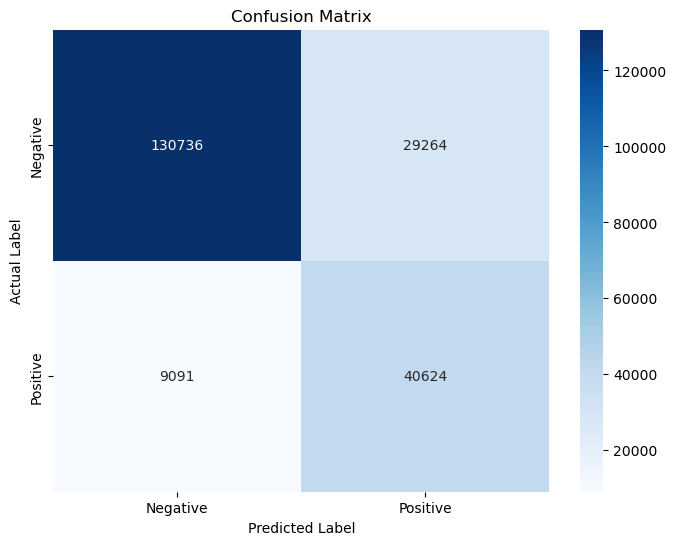

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# Test With Custom Input

In [52]:
def predict_sentiment(text):
    # Clean the input text
    cleaned = clean_text(text)
    
    # Vectorize using the same tfidf
    vectorized = tfidf.transform([cleaned])
    
    # Predict
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    # Display result
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    confidence = probability[prediction] * 100
    
    print(f"Tweet      : {text}")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {confidence:.2f}%")
    print("-" * 50)

# Test with sample tweets
predict_sentiment("I am so happy today! Everything is going great!")
predict_sentiment("I hate this! Worst day of my life.")
predict_sentiment("The weather is so gloomy and I feel terrible.")
predict_sentiment("Just got promoted at work! So excited!")

Tweet      : I am so happy today! Everything is going great!
Sentiment  : Positive 😊
Confidence : 94.85%
--------------------------------------------------
Tweet      : I hate this! Worst day of my life.
Sentiment  : Negative 😞
Confidence : 99.17%
--------------------------------------------------
Tweet      : The weather is so gloomy and I feel terrible.
Sentiment  : Negative 😞
Confidence : 98.29%
--------------------------------------------------
Tweet      : Just got promoted at work! So excited!
Sentiment  : Positive 😊
Confidence : 82.77%
--------------------------------------------------
